### Import libraries

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

from resmip import Image, RTStructureSet

## READ DICOM AND SAVE NII 

### Define path

In [2]:
dicom_path = Path.cwd().parent / "tests" / "Dicom" / "IBSI1_CT_phantom"
outputs = Path.cwd().parent / "src" /"wrk"
dicom_path, outputs

(WindowsPath('C:/Users/ubeira.mariagiulia/OneDrive - Ospedale San Raffaele/progetti_SR/PycharmProjects/resmip/tests/Dicom/IBSI1_CT_phantom'),
 WindowsPath('C:/Users/ubeira.mariagiulia/OneDrive - Ospedale San Raffaele/progetti_SR/PycharmProjects/resmip/src/wrk'))

### Read original dicom image and dicom rtstruct

In [ ]:
# Read original dicom image
image_ct = Image.read(dicom_path / "CT_00000")
# Read original dicom rtstruct
path_rt = list((dicom_path).glob("RTst_*/*.dcm"))[0]
structures = RTStructureSet.read(path_rt, reference_image = image_ct)
print(structures)

[RTStructure(name='GTV-1', mask=<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x00000259D325A220> >)]


In [ ]:
image_ct.size

(204, 201, 60)

### Plot image and first structure

In [5]:
image_array = image_ct.numpy()
mask_array = structures["GTV-1"].numpy()
image_array.shape, mask_array.shape

((60, 201, 204), (60, 201, 204))

In [6]:
index = 30

Text(0.5, 1.0, 'original * first mask')

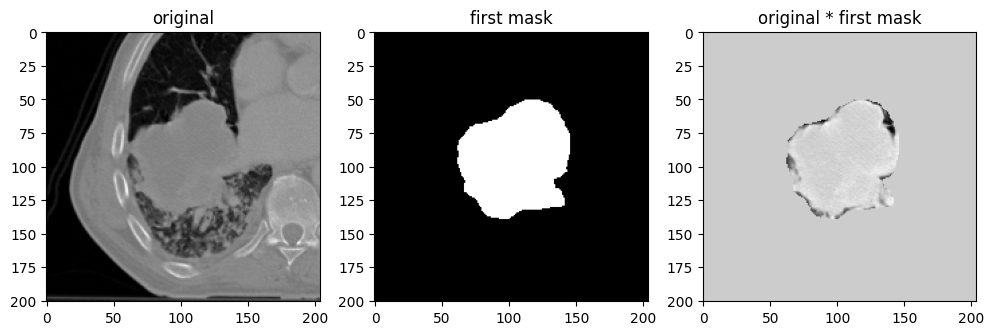

In [7]:
fig, ax = plt.subplots(1,3, figsize=(12,35))
ax[0].imshow(image_array[index], cmap='gray')
ax[0].set_title('original')
ax[1].imshow(mask_array[index], cmap='gray')
ax[1].set_title('first mask')
ax[2].imshow(image_array[index]*mask_array[index], cmap='gray')
ax[2].set_title('original * first mask')

### Check how the header of rt struct is

In [25]:
import pydicom as pydcm
dicom_struct = pydcm.dcmread(path_rt, force=True)
dicom_struct

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 194
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: RT Structure Set Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.2.319182855012857526824888634150646740410
(0002, 0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.40.0.13.1.1
(0002, 0013) Implementation Version Name         SH: 'dcm4che-2.0'
-------------------------------------------------
(0008, 0012) Instance Creation Date              DA: '20160804'
(0008, 0013) Instance Creation Time              TM: '121906.999'
(0008, 0016) SOP Class UID                       UI: RT Structure Set Storage
(0008, 0018) SOP Instance UID                    UI: 1.3.6.1.4.1.9590.100.1.2.319182855012857526824888634150646740410
(0008, 0020) Study Date                  

In [26]:
dicom_struct["PatientID"], dicom_struct["PatientName"], dicom_struct[0x0008, 0x0090]

((0010, 0020) Patient ID                          LO: '1',
 (0010, 0010) Patient's Name                      PN: 'PAT1',
 (0008, 0090) Referring Physician's Name          PN: '')

### Define path where to save nii files

In [9]:
save_path = outputs / "prove"
save_path.mkdir(exist_ok=True, parents=True)

### Save nifti (image and rt structure)

In [ ]:
image_ct.write(save_path / "img.nii.gz")
structures["GTV-1"].write(save_path, file_format = ".nii.gz")